# LSTMs with PyTorch — Sine Wave Prediction

The vanilla RNN struggles with **long-range dependencies** because gradients shrink exponentially
as they travel back through time (the vanishing gradient problem).

**LSTMs** (Long Short-Term Memory networks) solve this with two states:
- **Hidden state** `h_t`: short-term memory (same role as in a vanilla RNN)
- **Cell state** `c_t`: long-term memory — a highway for gradients to flow unchanged

Three gates control information flow:
- **Forget gate**: what to erase from `c_{t-1}`
- **Input gate**: what new information to write to `c_t`
- **Output gate**: what to expose as `h_t`

In this exercise you'll predict sine wave values from a sliding window of past values.

## Key Concept: LSTM Gates — Gated Memory

The LSTM (Hochreiter & Schmidhuber, 1997) introduces a **cell state** `c_t`
— a highway along which gradients can flow across many timesteps with
minimal distortion.

**Four computations per timestep** (all using `[h_{t-1}, x_t]` as input):

| Gate | Formula | Role |
|------|---------|------|
| Forget | `f = σ(W_f·[h,x] + b_f)` | What fraction of `c_{t-1}` to *keep* |
| Input  | `i = σ(W_i·[h,x] + b_i)` | How much *new* information to write |
| Cell update | `g = tanh(W_g·[h,x] + b_g)` | *What* new information to write |
| Output | `o = σ(W_o·[h,x] + b_o)` | What to expose as hidden state |

**State updates:**
```
c_t  =  f ⊙ c_{t-1}  +  i ⊙ g       ← cell state (long-term memory)
h_t  =  o ⊙ tanh(c_t)               ← hidden state (short-term/output)
```

**Why does this solve vanishing gradients?**
When `f ≈ 1` (forget gate open), `c_t ≈ c_{t-1} + i ⊙ g` — the gradient
∂c_t/∂c_{t-1} ≈ 1 regardless of how many timesteps separate two events.
This "gradient highway" lets the LSTM remember things from hundreds of
steps ago without the exponential decay that cripples vanilla RNNs.

> 📖 [Colah — Understanding LSTMs](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)

## Step 1: Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False

print('PyTorch version:', torch.__version__)

## Key Concept: Devices and `.to(device)`

PyTorch can run computations on the **CPU** or a **GPU** (NVIDIA CUDA or
Apple Silicon MPS). Moving a tensor or model to a device means its data and
computations live there.

```python
device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')

model = MyModel().to(device)   # moves all weight tensors to device
X = X.to(device)               # moves input data to the same device
```

**Rule:** model and data must be on the *same* device — mixing them raises
a `RuntimeError`. Call `.to(device)` on both.

> 📖 [PyTorch — CUDA semantics](https://pytorch.org/docs/stable/notes/cuda.html)


## Key Concept: `Dataset` and `DataLoader`

`DataLoader` handles batching, shuffling, and parallel data loading so your
training loop stays simple.

```python
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_train, y_train)   # pairs inputs with labels
loader  = DataLoader(dataset,
                     batch_size=64,
                     shuffle=True)           # reshuffles every epoch

for Xb, yb in loader:                       # Xb: (64, ...) one mini-batch
    ...
```

Key parameters:
- `batch_size` — number of samples per gradient update
- `shuffle=True` — randomise order each epoch (always use for training)
- `num_workers` — background processes for loading (set to 2-4 on most machines)

> 📖 [PyTorch — Writing a Custom Dataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html)


## Step 2: Generate the Sine Wave Dataset

We generate 200 points of a sine wave. This is our time series.

In [ ]:
# TODO: use np.linspace to create t from 0 to 4*pi with 200 points
t = ...
# TODO: compute data = np.sin(t).astype(np.float32)
data = ...

print(f'Data shape: {data.shape}')
print(f'Min: {data.min():.3f}, Max: {data.max():.3f}')
print(f'First 5 values: {data[:5]}')

## Step 3: Create Sliding Window Sequences

With `seq_len=20`, each training sample is:
- **Input** `X[i]`: `data[i : i+seq_len]` — the last 20 values, shape `(seq_len, 1)`
- **Target** `y[i]`: `data[i+seq_len]` — the next value to predict, shape `(1,)`

The `1` in the last dimension indicates 1 feature (the sine value at that timestep).

In [ ]:
def create_sequences(data, seq_len=20):
    """
    Returns:
      X: shape (N, seq_len, 1) as float32 tensor
      y: shape (N, 1) as float32 tensor
    """
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        # TODO: append data[i:i+seq_len] reshaped to (seq_len, 1)
        xs.append(...)
        # TODO: append data[i+seq_len] reshaped to (1,)
        ys.append(...)
    # TODO: return torch tensors converted from numpy arrays
    return ..., ...

X, y = create_sequences(data, seq_len=20)
print('X shape:', X.shape)
print('y shape:', y.shape)

## Step 4: Train/Test Split

Split 80% for training, 20% for testing. Preserve temporal order — do NOT shuffle.

In [ ]:
# TODO: compute split_idx as int(0.8 * len(X))
split_idx = ...

# TODO: create X_train, X_test, y_train, y_test
X_train, X_test = ...
y_train, y_test = ...

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

## Step 5: Define the LSTM Model

Key difference from `nn.RNN`:
- `nn.LSTM` returns `(output, (h_n, c_n))` — a **tuple** for the hidden state
- `h_n` is the hidden state, `c_n` is the cell state
- We use `output[:, -1, :]` — the last timestep's output — for regression

With `num_layers=2`, the LSTM is stacked: output of layer 1 feeds into layer 2.

In [ ]:
class SineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # TODO: define self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.lstm = ...
        # TODO: define self.fc = nn.Linear(hidden_size, 1)
        self.fc = ...

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        # TODO: pass x through self.lstm
        # Unpack: out, (h_n, c_n) = self.lstm(x)
        out, (h_n, c_n) = ...

        # TODO: take last timestep: out[:, -1, :] shape (batch, hidden_size)
        last_out = ...

        # TODO: apply self.fc -> shape (batch, 1)
        return self.fc(last_out)

model = SineLSTM()
print(model)

### Concept Check: LSTM Architecture

**Q1.** `nn.LSTM` returns `(output, (h_n, c_n))`.
`nn.RNN` returns `(output, h_n)`.
What is `c_n` and why doesn't `nn.RNN` have it?

**Q2.** In `SineLSTM.forward` we use `out[:, -1, :]` — the last timestep's
output. An alternative is `h_n[-1]` (the final hidden state from the last
layer). Are these always identical for LSTM? Under what conditions might
they differ?

**Q3.** With `num_layers=2`, the second LSTM layer's input is the output
sequence of the first layer. What shape does this input have, and why is
stacking layers beneficial?

In [ ]:
# Q1:
# Q2:
# Q3:


## Step 6: Training Loop

In [ ]:
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

criterion    = nn.MSELoss()   # regression: mean((pred - target)²) over the batch
optimizer    = optim.Adam(model.parameters(), lr=0.001)
epoch_losses = []

for epoch in range(100):
    model.train()
    total = 0
    for Xb, yb in train_loader:
        # For MPS/CUDA: data must be on the same device as model weights.
        Xb, yb = Xb.to(device), yb.to(device)
        pred = model(Xb)            # Xb: (16,20,1) → pred: (16,1) via LSTM + linear

        # MSELoss averages squared differences element-wise over all (B, 1) values.
        loss = criterion(pred, yb)  # yb: (16,1)

        optimizer.zero_grad()       # accumulation prevention — reset before backward
        loss.backward()             # BPTT through 20 timesteps; LSTM gates get gradients too
        optimizer.step()

        total += loss.item()
    avg = total / len(train_loader)
    epoch_losses.append(avg)
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Loss: {avg:.6f}')

## Step 7: Evaluate on Test Set

In [ ]:
model.eval()
with torch.no_grad():
    # TODO: get predictions on X_test
    test_preds = ...
    test_loss = criterion(test_preds, y_test)
    print(f'Test MSE: {test_loss.item():.6f}')

## Step 8: Visualize Predictions vs Actuals

In [ ]:
model.eval()
with torch.no_grad():
    preds = model(X_test).squeeze().numpy()
    actuals = y_test.squeeze().numpy()

print('Predicted vs Actual (first 10):')
for i in range(10):
    print(f'  Pred: {preds[i]:.4f} | Actual: {actuals[i]:.4f}')

if HAS_MATPLOTLIB:
    plt.figure(figsize=(12, 4))
    plt.plot(actuals, label='Actual', linewidth=2)
    plt.plot(preds, label='Predicted', linewidth=2, linestyle='--')
    plt.legend()
    plt.title('LSTM Sine Wave Prediction')
    plt.xlabel('Time step')
    plt.ylabel('Value')
    plt.show()

## Step 9: Compare LSTM vs RNN

Rebuild the same architecture but use `nn.RNN` instead of `nn.LSTM`. Train and compare.

Note: `nn.RNN` returns `(output, h_n)` — no cell state tuple.

In [ ]:
class SineRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super().__init__()
        # TODO: define self.rnn = nn.RNN(...) mirroring SineLSTM
        self.rnn = ...
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # TODO: out, h_n = self.rnn(x)
        out, h_n = ...
        return self.fc(out[:, -1, :])

rnn_model = SineRNN()
optimizer_rnn = optim.Adam(rnn_model.parameters(), lr=0.001)

# TODO: train rnn_model for 100 epochs (same loop as above)
for epoch in range(100):
    pass

# TODO: evaluate test MSE and compare
print('\nFinal comparison:')
print(f'  LSTM Test MSE: {test_loss.item():.6f}')
# print(f'  RNN  Test MSE: ...')

### Concept Check: Sequence Models — LSTM vs RNN vs What's Next

**Q1.** You observed LSTM outperforms RNN on this 20-step sine wave.
How do you expect the performance gap to change on a 200-step sequence?
On a 5-step sequence? Why?

**Q2.** Both RNN and LSTM process tokens *sequentially* — each step
depends on the previous hidden state. Name the key computational
bottleneck this creates, and explain in one sentence how the Transformer
architecture (next lesson) removes it.

**Q3.** The LSTM cell state solves vanishing *but not* exploding gradients.
Why is exploding still possible in LSTMs, and what is the standard fix?

In [ ]:
# Q1:
# Q2:
# Q3:


## Step 10: Visualize the LSTM Cell Architecture

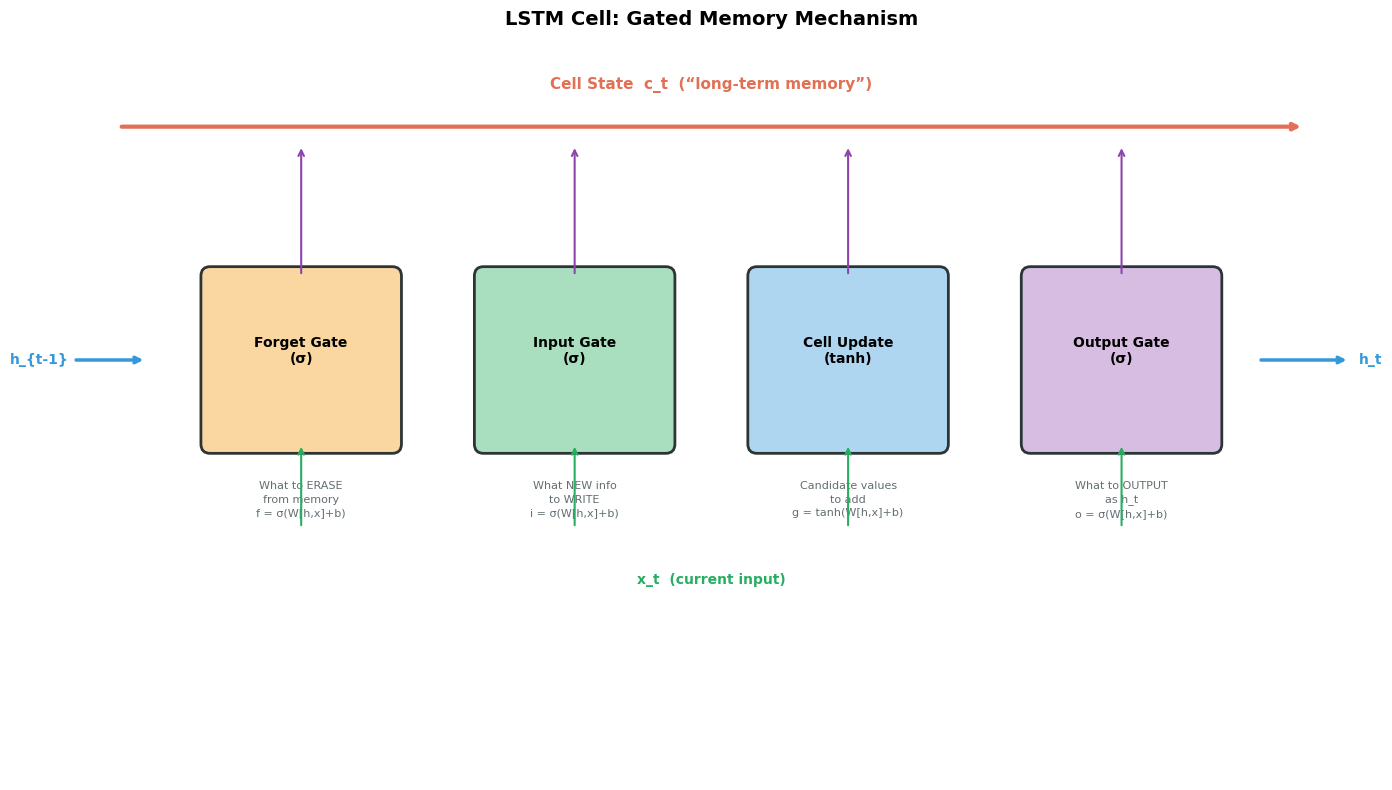

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('LSTM Cell: Gated Memory Mechanism', fontsize=14, fontweight='bold')

# Cell state highway (top)
ax.annotate('', xy=(13.5, 7.0), xytext=(0.5, 7.0),
            arrowprops=dict(arrowstyle='->', color='#e17055', lw=3))
ax.text(7, 7.4, 'Cell State  c_t  (“long-term memory”)', ha='center',
        fontsize=11, color='#e17055', fontweight='bold')

gates = [
    (2.5,  'Forget Gate\n(σ)', '#FAD7A0',
     'What to ERASE\nfrom memory\nf = σ(W[h,x]+b)'),
    (5.5,  'Input Gate\n(σ)', '#A9DFBF',
     'What NEW info\nto WRITE\ni = σ(W[h,x]+b)'),
    (8.5,  'Cell Update\n(tanh)', '#AED6F1',
     'Candidate values\nto add\ng = tanh(W[h,x]+b)'),
    (11.5, 'Output Gate\n(σ)', '#D7BDE2',
     'What to OUTPUT\nas h_t\no = σ(W[h,x]+b)'),
]
for x, label, color, desc in gates:
    rect = mpatches.FancyBboxPatch((x - 1.0, 3.6), 2.0, 1.8,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='#2d3436', lw=2)
    ax.add_patch(rect)
    ax.text(x, 4.6, label, ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(x, 3.2, desc, ha='center', va='top', fontsize=8, color='#636e72', linespacing=1.4)
    ax.annotate('', xy=(x, 6.8), xytext=(x, 5.4),
                arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=1.5))

# h_{t-1} input
ax.annotate('', xy=(0.8, 4.5), xytext=(0.0, 4.5),
            arrowprops=dict(arrowstyle='->', color='#3498db', lw=2.5))
ax.text(-0.05, 4.5, 'h_{t-1}', ha='right', va='center', fontsize=10,
        color='#3498db', fontweight='bold')

# x_t inputs
ax.text(7, 2.1, 'x_t  (current input)', ha='center', fontsize=10,
        color='#27ae60', fontweight='bold')
for gx in [2.5, 5.5, 8.5, 11.5]:
    ax.annotate('', xy=(gx, 3.6), xytext=(gx, 2.7),
                arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5))

# h_t output
ax.annotate('', xy=(14.0, 4.5), xytext=(13.0, 4.5),
            arrowprops=dict(arrowstyle='->', color='#3498db', lw=2.5))
ax.text(14.1, 4.5, 'h_t', ha='left', va='center', fontsize=10,
        color='#3498db', fontweight='bold')

plt.tight_layout()
plt.show()


## Bonus: Multi-layer LSTM with Dropout

`nn.LSTM` supports `dropout` between layers (applied to all layers except the last).
Try adding dropout for regularization.

In [ ]:
class SineLSTMDeep(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: nn.LSTM with input_size=1, hidden_size=32, num_layers=3, dropout=0.2
        self.lstm = ...
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# TODO: train and compare test MSE with 2-layer version